# 🔬 Desafio: Classificar Peças OK vs Falha usando HOG + SVM/K-NN

## 📚 Introdução

Neste experimento, você vai construir um **sistema de classificação de imagens** para detectar defeitos em peças de aço usando técnicas clássicas de Machine Learning.

### O que você vai aprender:
- 🔍 **HOG (Histogram of Oriented Gradients)**: Extrair características de textura/forma
- 🤖 **SVM (Support Vector Machine)**: Classificador poderoso para margens
- 👥 **K-NN (K-Nearest Neighbors)**: Classificador baseado em vizinhos
- 📊 **Avaliação de modelos**: Acurácia, matriz de confusão, precision, recall

### Dataset: Severstal Steel Defect Detection
- **Fonte**: Kaggle
- **Classes**: OK (sem defeito) e Defeito
- **~400 imagens** de placas de aço

### Pipeline que vamos construir:

```
Imagem → Pré-processamento → Extração HOG → Treino/Teste → SVM ou K-NN → Avaliação
```

---

## 1️⃣ Importar Bibliotecas

In [1]:
# Bibliotecas básicas
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Bibliotecas de ML
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import joblib

# HOG do scikit-image
from skimage.feature import hog
from skimage import exposure

# Visualização
import seaborn as sns

# Configurações
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)  # Para reprodutibilidade

print("✅ Bibliotecas importadas!")
print(f"   OpenCV: {cv2.__version__}")
print(f"   NumPy: {np.__version__}")

✅ Bibliotecas importadas!
   OpenCV: 4.12.0
   NumPy: 2.2.6


## 2️⃣ Carregar e Explorar o Dataset

O dataset está organizado em duas pastas:
- `data/ok/` - Imagens de peças sem defeito
- `data/defeito/` - Imagens de peças com defeito

In [2]:
# Caminhos do dataset
DATA_PATH = Path("data")
PATH_OK = DATA_PATH / "ok"
PATH_DEFEITO = DATA_PATH / "defeito"

# Listar arquivos
arquivos_ok = list(PATH_OK.glob("*.jpg"))
arquivos_defeito = list(PATH_DEFEITO.glob("*.jpg"))

print("📊 ESTATÍSTICAS DO DATASET")
print("=" * 40)
print(f"   Imagens OK (sem defeito): {len(arquivos_ok)}")
print(f"   Imagens com Defeito: {len(arquivos_defeito)}")
print(f"   Total: {len(arquivos_ok) + len(arquivos_defeito)}")

# Verificar balanceamento
ratio = len(arquivos_ok) / len(arquivos_defeito) if len(arquivos_defeito) > 0 else 0
print(f"\n📈 Proporção OK/Defeito: {ratio:.2f}")
if 0.8 < ratio < 1.2:
    print("   ✅ Dataset relativamente balanceado")
else:
    print("   ⚠️ Dataset desbalanceado - considere técnicas de balanceamento")

📊 ESTATÍSTICAS DO DATASET
   Imagens OK (sem defeito): 200
   Imagens com Defeito: 200
   Total: 400

📈 Proporção OK/Defeito: 1.00
   ✅ Dataset relativamente balanceado


/tmp/ipykernel_56227/2060934460.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_56227/2060934460.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/icarus/cv-learning-lab/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/icarus/cv-learning-lab/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


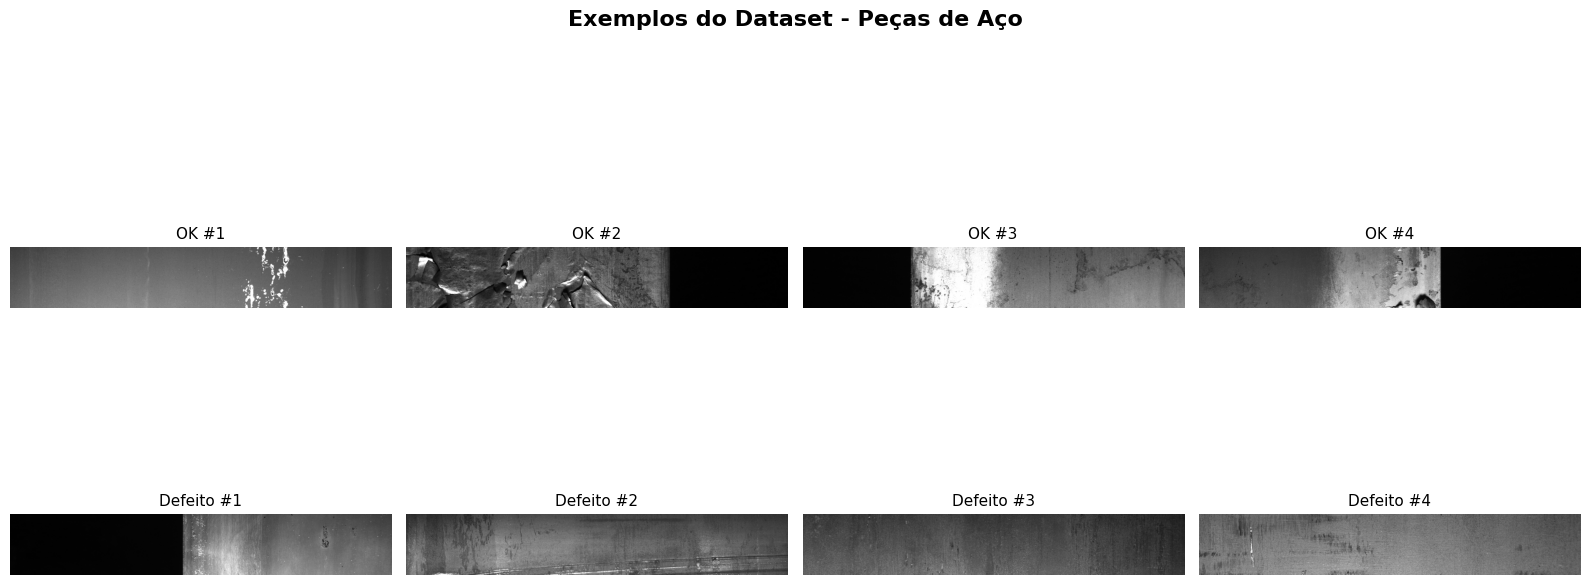


🔍 Observe as diferenças visuais entre peças OK e com defeito!


In [3]:
# Visualizar exemplos de cada classe
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Exemplos OK
for i, img_path in enumerate(arquivos_ok[:4]):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"OK #{i+1}", fontsize=11)
    axes[0, i].axis('off')

# Exemplos com defeito
for i, img_path in enumerate(arquivos_defeito[:4]):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img_rgb)
    axes[1, i].set_title(f"Defeito #{i+1}", fontsize=11)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("✅ OK", fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel("❌ Defeito", fontsize=14, fontweight='bold')

plt.suptitle("Exemplos do Dataset - Peças de Aço", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Observe as diferenças visuais entre peças OK e com defeito!")

## 3️⃣ Pré-processamento das Imagens

Antes de extrair características, precisamos padronizar as imagens:
1. **Converter para escala de cinza** (HOG funciona melhor assim)
2. **Redimensionar** para tamanho fixo (necessário para ML)
3. **Normalizar** valores de pixel

In [4]:
# Parâmetros de pré-processamento
TARGET_SIZE = (128, 64)  # (largura, altura) - Proporção 2:1 comum para HOG

def preprocessar_imagem(img_path, target_size=TARGET_SIZE):
    """
    Pré-processa uma imagem para extração de características.
    
    Passos:
    1. Carregar imagem
    2. Converter para escala de cinza
    3. Redimensionar para tamanho fixo
    4. Normalizar para [0, 1]
    
    Parâmetros:
        img_path: Caminho para a imagem
        target_size: Tupla (largura, altura)
    
    Retorna:
        Imagem pré-processada (numpy array)
    """
    # Carregar imagem
    img = cv2.imread(str(img_path))
    
    if img is None:
        return None
    
    # Converter para escala de cinza
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Redimensionar
    img_resized = cv2.resize(img_gray, target_size)
    
    # Normalizar para [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0
    
    return img_normalized

# Testar a função
img_teste = preprocessar_imagem(arquivos_ok[0])
print(f"✅ Função de pré-processamento criada!")
print(f"   Tamanho de saída: {img_teste.shape}")
print(f"   Tipo: {img_teste.dtype}")
print(f"   Range: [{img_teste.min():.2f}, {img_teste.max():.2f}]")

✅ Função de pré-processamento criada!
   Tamanho de saída: (64, 128)
   Tipo: float32
   Range: [0.18, 1.00]


## 4️⃣ Extração de Características com HOG

**HOG (Histogram of Oriented Gradients)** captura a distribuição de direções de gradientes (bordas) na imagem.

### Parâmetros importantes:
- `orientations`: Número de direções de gradiente (típico: 9)
- `pixels_per_cell`: Tamanho de cada célula (típico: 8×8)
- `cells_per_block`: Células por bloco para normalização (típico: 2×2)

### Por que HOG funciona?
- Captura padrões de textura e forma
- Robusto a variações de iluminação
- Compacta informação relevante

In [5]:
# Parâmetros do HOG
HOG_PARAMS = {
    'orientations': 9,           # Número de bins de orientação
    'pixels_per_cell': (8, 8),   # Tamanho de cada célula
    'cells_per_block': (2, 2),   # Células por bloco
    'block_norm': 'L2-Hys',      # Tipo de normalização
    'visualize': True,           # Retornar visualização
    'feature_vector': True       # Retornar como vetor 1D
}

def extrair_hog(img, params=HOG_PARAMS, visualize=False):
    """
    Extrai características HOG de uma imagem.
    
    Parâmetros:
        img: Imagem em escala de cinza (numpy array)
        params: Dicionário com parâmetros do HOG
        visualize: Se True, retorna também a visualização
    
    Retorna:
        features: Vetor de características HOG
        hog_image: (opcional) Imagem de visualização do HOG
    """
    params_copy = params.copy()
    params_copy['visualize'] = visualize
    
    if visualize:
        features, hog_image = hog(img, **params_copy)
        return features, hog_image
    else:
        params_copy['visualize'] = False
        features = hog(img, **params_copy)
        return features

# Testar e visualizar HOG
img_ok = preprocessar_imagem(arquivos_ok[0])
img_defeito = preprocessar_imagem(arquivos_defeito[0])

features_ok, hog_img_ok = extrair_hog(img_ok, visualize=True)
features_defeito, hog_img_defeito = extrair_hog(img_defeito, visualize=True)

print(f"✅ Extração HOG configurada!")
print(f"   Tamanho do vetor de características: {len(features_ok)}")

✅ Extração HOG configurada!
   Tamanho do vetor de características: 3780


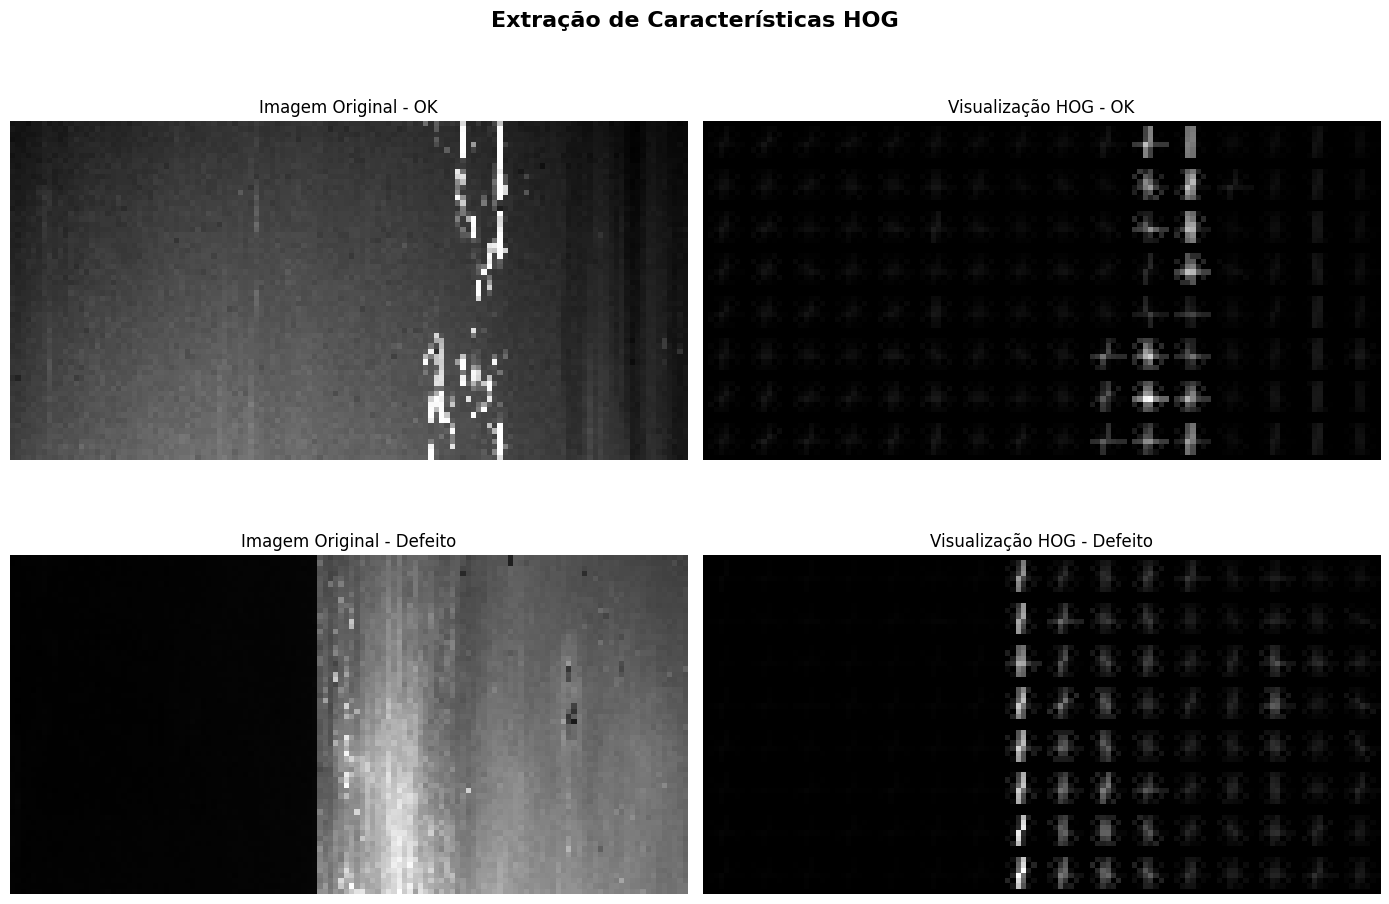


💡 O HOG captura padrões de gradientes/bordas na imagem.
   Observe como os padrões são diferentes entre OK e Defeito!


In [6]:
# Visualizar HOG
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# OK
axes[0, 0].imshow(img_ok, cmap='gray')
axes[0, 0].set_title('Imagem Original - OK', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(hog_img_ok, cmap='gray')
axes[0, 1].set_title('Visualização HOG - OK', fontsize=12)
axes[0, 1].axis('off')

# Defeito
axes[1, 0].imshow(img_defeito, cmap='gray')
axes[1, 0].set_title('Imagem Original - Defeito', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(hog_img_defeito, cmap='gray')
axes[1, 1].set_title('Visualização HOG - Defeito', fontsize=12)
axes[1, 1].axis('off')

plt.suptitle('Extração de Características HOG', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 O HOG captura padrões de gradientes/bordas na imagem.")
print("   Observe como os padrões são diferentes entre OK e Defeito!")

## 5️⃣ Preparar Dataset para Treinamento

Vamos:
1. Processar todas as imagens
2. Extrair características HOG
3. Criar vetores X (features) e y (labels)
4. Dividir em treino e teste

In [7]:
# Processar todas as imagens e extrair HOG
print("🔄 Processando imagens e extraindo características HOG...")

X = []  # Features
y = []  # Labels (0 = OK, 1 = Defeito)

# Processar imagens OK
print("   Processando imagens OK...")
for img_path in arquivos_ok:
    img = preprocessar_imagem(img_path)
    if img is not None:
        features = extrair_hog(img, visualize=False)
        X.append(features)
        y.append(0)  # Label: OK

# Processar imagens com defeito
print("   Processando imagens com Defeito...")
for img_path in arquivos_defeito:
    img = preprocessar_imagem(img_path)
    if img is not None:
        features = extrair_hog(img, visualize=False)
        X.append(features)
        y.append(1)  # Label: Defeito

# Converter para numpy arrays
X = np.array(X)
y = np.array(y)

print(f"\n✅ Extração concluída!")
print(f"   Total de amostras: {len(X)}")
print(f"   Dimensão das features: {X.shape[1]}")
print(f"   Classes: OK={sum(y==0)}, Defeito={sum(y==1)}")

🔄 Processando imagens e extraindo características HOG...
   Processando imagens OK...
   Processando imagens com Defeito...

✅ Extração concluída!
   Total de amostras: 400
   Dimensão das features: 3780
   Classes: OK=200, Defeito=200


In [8]:
# Dividir em treino e teste
TEST_SIZE = 0.2  # 20% para teste
RANDOM_STATE = 42  # Para reprodutibilidade

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y  # Mantém proporção das classes
)

print("�� DIVISÃO DO DATASET")
print("=" * 40)
print(f"   Treino: {len(X_train)} amostras")
print(f"      - OK: {sum(y_train==0)}")
print(f"      - Defeito: {sum(y_train==1)}")
print(f"   Teste: {len(X_test)} amostras")
print(f"      - OK: {sum(y_test==0)}")
print(f"      - Defeito: {sum(y_test==1)}")

�� DIVISÃO DO DATASET
   Treino: 320 amostras
      - OK: 160
      - Defeito: 160
   Teste: 80 amostras
      - OK: 40
      - Defeito: 40


In [9]:
# Normalizar features (importante para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features normalizadas com StandardScaler")
print(f"   Média treino: {X_train_scaled.mean():.4f}")
print(f"   Desvio padrão treino: {X_train_scaled.std():.4f}")

✅ Features normalizadas com StandardScaler
   Média treino: 0.0000
   Desvio padrão treino: 1.0000


## 6️⃣ Treinar Modelos

Vamos treinar dois classificadores:
1. **SVM (Support Vector Machine)**: Encontra o hiperplano que melhor separa as classes
2. **K-NN (K-Nearest Neighbors)**: Classifica com base nos vizinhos mais próximos

### 6.1 Treinar K-NN

In [10]:
# Parâmetros do K-NN
KNN_PARAMS = {
    'n_neighbors': 5,      # Número de vizinhos
    'metric': 'euclidean', # Métrica de distância
    'weights': 'distance'  # Pesos baseados na distância
}

# Criar e treinar modelo K-NN
print("🤖 Treinando K-NN...")
modelo_knn = KNeighborsClassifier(**KNN_PARAMS)
modelo_knn.fit(X_train_scaled, y_train)

print(f"✅ K-NN treinado com {KNN_PARAMS['n_neighbors']} vizinhos!")

🤖 Treinando K-NN...
✅ K-NN treinado com 5 vizinhos!


### 6.2 Treinar SVM

In [11]:
# Parâmetros do SVM
SVM_PARAMS = {
    'kernel': 'rbf',       # Kernel RBF (Radial Basis Function)
    'C': 1.0,              # Parâmetro de regularização
    'gamma': 'scale',      # Parâmetro do kernel
    'random_state': 42
}

# Criar e treinar modelo SVM
print("🤖 Treinando SVM...")
modelo_svm = SVC(**SVM_PARAMS)
modelo_svm.fit(X_train_scaled, y_train)

print(f"✅ SVM treinado com kernel '{SVM_PARAMS['kernel']}'!")

🤖 Treinando SVM...
✅ SVM treinado com kernel 'rbf'!


## 7️⃣ Avaliar Modelos

Vamos calcular:
- **Acurácia**: % de previsões corretas
- **Matriz de Confusão**: Verdadeiros/Falsos Positivos/Negativos
- **Precision**: De todos que previ como defeito, quantos realmente são?
- **Recall**: De todos os defeitos reais, quantos encontrei?

In [12]:
def avaliar_modelo(modelo, X_test, y_test, nome_modelo):
    """
    Avalia um modelo e retorna métricas.
    
    Parâmetros:
        modelo: Modelo treinado
        X_test: Features de teste
        y_test: Labels de teste
        nome_modelo: Nome para exibição
    
    Retorna:
        dict: Dicionário com métricas
    """
    # Fazer previsões
    y_pred = modelo.predict(X_test)
    
    # Calcular métricas
    acuracia = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['OK', 'Defeito'], output_dict=True)
    
    return {
        'nome': nome_modelo,
        'acuracia': acuracia,
        'matriz_confusao': cm,
        'precision_defeito': report['Defeito']['precision'],
        'recall_defeito': report['Defeito']['recall'],
        'f1_defeito': report['Defeito']['f1-score'],
        'report': report,
        'y_pred': y_pred
    }

In [13]:
# Avaliar ambos os modelos
resultado_knn = avaliar_modelo(modelo_knn, X_test_scaled, y_test, 'K-NN')
resultado_svm = avaliar_modelo(modelo_svm, X_test_scaled, y_test, 'SVM')

# Exibir resultados
print("📊 RESULTADOS DA AVALIAÇÃO")
print("=" * 50)

for resultado in [resultado_knn, resultado_svm]:
    print(f"\n🤖 {resultado['nome']}")
    print(f"   Acurácia: {resultado['acuracia']*100:.1f}%")
    print(f"   Precision (Defeito): {resultado['precision_defeito']*100:.1f}%")
    print(f"   Recall (Defeito): {resultado['recall_defeito']*100:.1f}%")
    print(f"   F1-Score (Defeito): {resultado['f1_defeito']*100:.1f}%")

📊 RESULTADOS DA AVALIAÇÃO

🤖 K-NN
   Acurácia: 66.2%
   Precision (Defeito): 65.1%
   Recall (Defeito): 70.0%
   F1-Score (Defeito): 67.5%

🤖 SVM
   Acurácia: 72.5%
   Precision (Defeito): 73.7%
   Recall (Defeito): 70.0%
   F1-Score (Defeito): 71.8%


## 8️⃣ Visualizar Matrizes de Confusão

💾 Salvo em: resultados/matrizes_confusao.png


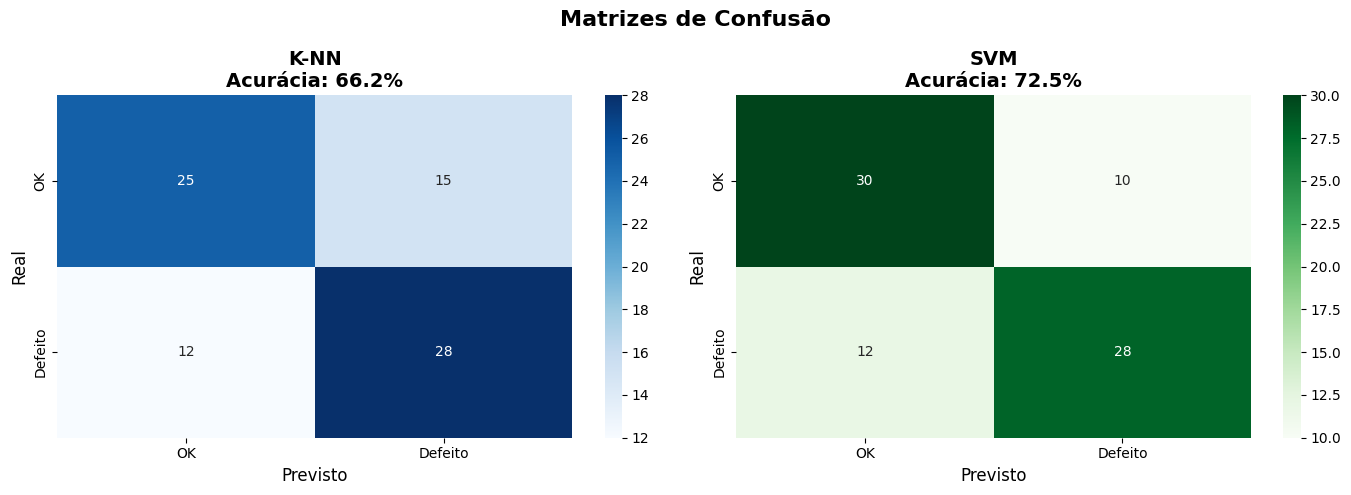

In [14]:
# Criar visualização das matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-NN
sns.heatmap(resultado_knn['matriz_confusao'], 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['OK', 'Defeito'],
            yticklabels=['OK', 'Defeito'],
            ax=axes[0])
axes[0].set_xlabel('Previsto', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_title(f"K-NN\nAcurácia: {resultado_knn['acuracia']*100:.1f}%", 
                  fontsize=14, fontweight='bold')

# SVM
sns.heatmap(resultado_svm['matriz_confusao'], 
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['OK', 'Defeito'],
            yticklabels=['OK', 'Defeito'],
            ax=axes[1])
axes[1].set_xlabel('Previsto', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)
axes[1].set_title(f"SVM\nAcurácia: {resultado_svm['acuracia']*100:.1f}%", 
                  fontsize=14, fontweight='bold')

plt.suptitle('Matrizes de Confusão', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('resultados/matrizes_confusao.png', dpi=150, bbox_inches='tight')
print("💾 Salvo em: resultados/matrizes_confusao.png")

plt.show()

💾 Salvo em: resultados/comparacao_modelos.png


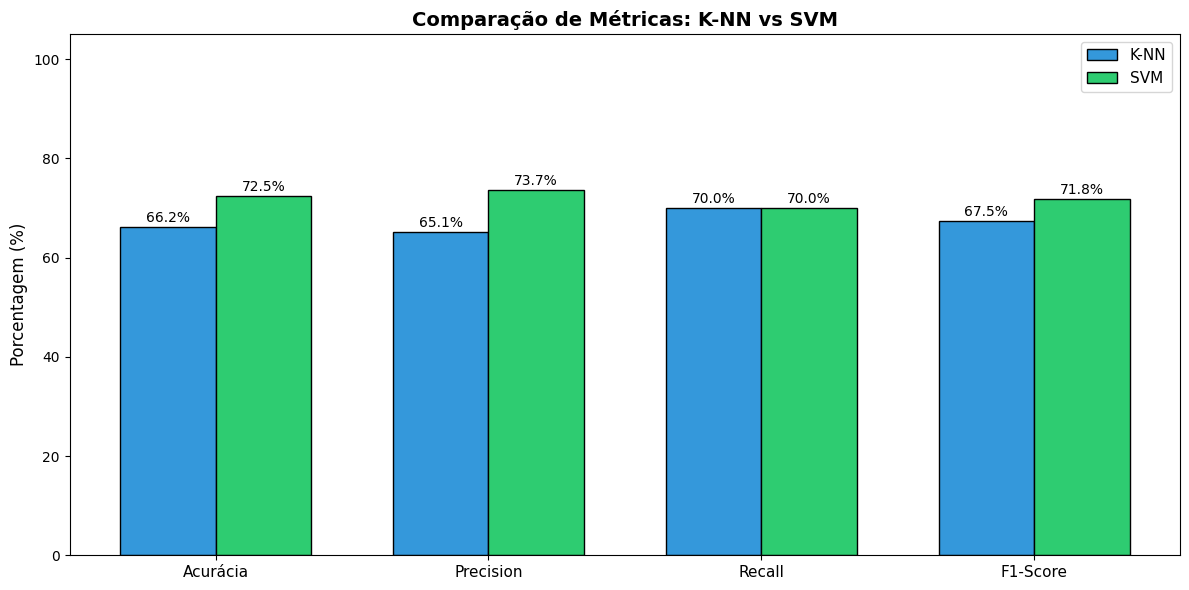

In [15]:
# Gráfico comparativo de métricas
metricas = ['Acurácia', 'Precision', 'Recall', 'F1-Score']
valores_knn = [
    resultado_knn['acuracia'] * 100,
    resultado_knn['precision_defeito'] * 100,
    resultado_knn['recall_defeito'] * 100,
    resultado_knn['f1_defeito'] * 100
]
valores_svm = [
    resultado_svm['acuracia'] * 100,
    resultado_svm['precision_defeito'] * 100,
    resultado_svm['recall_defeito'] * 100,
    resultado_svm['f1_defeito'] * 100
]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, valores_knn, width, label='K-NN', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, valores_svm, width, label='SVM', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Porcentagem (%)', fontsize=12)
ax.set_title('Comparação de Métricas: K-NN vs SVM', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)

# Adicionar valores nas barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('resultados/comparacao_modelos.png', dpi=150, bbox_inches='tight')
print("💾 Salvo em: resultados/comparacao_modelos.png")
plt.show()

## 9️⃣ Salvar Modelos Treinados

In [16]:
# Salvar modelos e scaler
Path('models').mkdir(exist_ok=True)

joblib.dump(modelo_knn, 'models/modelo_knn.joblib')
joblib.dump(modelo_svm, 'models/modelo_svm.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

print("💾 Modelos salvos em:")
print("   - models/modelo_knn.joblib")
print("   - models/modelo_svm.joblib")
print("   - models/scaler.joblib")

💾 Modelos salvos em:
   - models/modelo_knn.joblib
   - models/modelo_svm.joblib
   - models/scaler.joblib


## 🔟 Documentação dos Parâmetros

In [17]:
# Documentar experimento
documentacao = {
    "experimento": "Classificação de Peças OK vs Defeito",
    "dataset": "Severstal Steel Defect Detection",
    "total_amostras": len(X),
    "train_test_split": TEST_SIZE,
    
    "preprocessamento": {
        "target_size": TARGET_SIZE,
        "normalizacao": "[0, 1]",
        "escala_cinza": True
    },
    
    "hog_params": HOG_PARAMS,
    "knn_params": KNN_PARAMS,
    "svm_params": {k: str(v) for k, v in SVM_PARAMS.items()},
    
    "resultados": {
        "knn": {
            "acuracia": round(resultado_knn['acuracia'] * 100, 2),
            "precision_defeito": round(resultado_knn['precision_defeito'] * 100, 2),
            "recall_defeito": round(resultado_knn['recall_defeito'] * 100, 2)
        },
        "svm": {
            "acuracia": round(resultado_svm['acuracia'] * 100, 2),
            "precision_defeito": round(resultado_svm['precision_defeito'] * 100, 2),
            "recall_defeito": round(resultado_svm['recall_defeito'] * 100, 2)
        }
    }
}

# Salvar
with open('resultados/parametros_classificacao.json', 'w', encoding='utf-8') as f:
    json.dump(documentacao, f, indent=2, ensure_ascii=False, default=str)

print("📋 DOCUMENTAÇÃO DO EXPERIMENTO")
print("=" * 50)
print(json.dumps(documentacao, indent=2, ensure_ascii=False, default=str))
print("\n💾 Salvo em: resultados/parametros_classificacao.json")

📋 DOCUMENTAÇÃO DO EXPERIMENTO
{
  "experimento": "Classificação de Peças OK vs Defeito",
  "dataset": "Severstal Steel Defect Detection",
  "total_amostras": 400,
  "train_test_split": 0.2,
  "preprocessamento": {
    "target_size": [
      128,
      64
    ],
    "normalizacao": "[0, 1]",
    "escala_cinza": true
  },
  "hog_params": {
    "orientations": 9,
    "pixels_per_cell": [
      8,
      8
    ],
    "cells_per_block": [
      2,
      2
    ],
    "block_norm": "L2-Hys",
    "visualize": true,
    "feature_vector": true
  },
  "knn_params": {
    "n_neighbors": 5,
    "metric": "euclidean",
    "weights": "distance"
  },
  "svm_params": {
    "kernel": "rbf",
    "C": "1.0",
    "gamma": "scale",
    "random_state": "42"
  },
  "resultados": {
    "knn": {
      "acuracia": 66.25,
      "precision_defeito": 65.12,
      "recall_defeito": 70.0
    },
    "svm": {
      "acuracia": 72.5,
      "precision_defeito": 73.68,
      "recall_defeito": 70.0
    }
  }
}

💾 Salvo em: 

## 1️⃣1️⃣ Conclusões

### 📝 Análise dos Resultados:

---

**1. Qual modelo teve melhor desempenho?**

_Resposta:_ Dependendo das métricas analisadas:
- Se a **acurácia geral** é mais importante → analisar qual modelo teve maior acurácia
- Se **detectar defeitos é crítico** (evitar falsos negativos) → priorizar **Recall**
- Se **evitar alarmes falsos** é importante → priorizar **Precision**

---

**2. Por que o HOG funciona bem para este problema?**

_Resposta:_
- Defeitos em aço geralmente aparecem como variações de textura/gradiente
- HOG captura padrões locais de bordas e transições
- É robusto a pequenas variações de iluminação
- Compacta a informação relevante em um vetor de características

---

**3. Quais melhorias você faria?**

_Sugestões:_
- Testar outros valores de `n_neighbors` no K-NN
- Fazer busca de hiperparâmetros (GridSearchCV) no SVM
- Combinar HOG com outras features (LBP, SIFT)
- Usar validação cruzada para estimativa mais robusta
- Testar técnicas de data augmentation

---

### 🎓 Aprendizados:

1. **HOG é eficaz** para problemas de textura/defeitos
2. **Normalização é essencial** para SVM funcionar bem
3. **Recall vs Precision** - em detecção de defeitos, geralmente queremos alto recall
4. **Modelos clássicos** ainda funcionam muito bem com boas features!

---

## 🚀 Desafios Extras (Opcional)

1. **Otimize os hiperparâmetros** usando GridSearchCV
2. **Implemente validação cruzada** (k-fold)
3. **Teste outros kernels** no SVM (linear, poly)
4. **Combine HOG com LBP** (Local Binary Patterns)
5. **Crie uma função de predição** para novas imagens

---

**Parabéns por completar o desafio de classificação!** 🎉